In [1]:
%pip install soccerplots

Note: you may need to restart the kernel to use updated packages.


In [2]:
# pandas: tabular data loading and filtering
# matplotlib.pyplot: figure rendering (managed internally by soccerplots)
# soccerplots.radar_chart.Radar: renders a comparative dual-player radar chart
#   with two overlapping filled polygons on the same axes, one per player.
#   Unlike PyPizza (percentile-based), this radar uses raw stat values scaled
#   to per-axis ranges, making it suitable for absolute value comparisons.
import pandas as pd
import matplotlib.pyplot as plt
from soccerplots.radar_chart import Radar

# Load the FBref stats CSV for the 2020-21 Premier League season.
# The 'Player' column uses the same "Full Name\url-slug" format as notebook 9
# and is cleaned in the next cell. This dataset covers all outfield positions,
# so player-level filtering to a specific position is applied downstream.
df = pd.read_csv('data/radars10.csv')
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt\Patrick-van-Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham\Tammy-Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams\Che-Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo\Tosin-Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián\Adrian,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches


In [3]:
# Clean the Player column using the same FBref backslash-split pattern from notebook 9.
# str.split('\\', expand=True)[0] keeps only the human-readable full name,
# discarding the URL slug. This is required before filtering by player name with ==.
df['Player'] = df['Player'].str.split('\\', expand=True)[0]
df.Player.unique()

array(['Patrick van Aanholt', 'Tammy Abraham', 'Che Adams',
       'Tosin Adarabioyo', 'Adrián', 'Sergio Agüero', 'Ola Aina',
       'Rayan Aït Nouri', 'Semi Ajayi', 'Nathan Aké', 'Marc Albrighton',
       'Thiago Alcántara', 'Toby Alderweireld', 'Rúnar Alex Rúnarsson',
       'Trent Alexander-Arnold', 'Ezgjan Alioski', 'Alisson', 'Allan',
       'Dele Alli', 'Miguel Almirón', 'Marcos Alonso', 'Steven Alzate',
       'Daniel Amartey', 'Ethan Ampadu', 'Joachim Andersen',
       'Elliot Anderson', 'Felipe Anderson', 'Michail Antonio',
       'Alphonse Areola', 'Stuart Armstrong', 'Kepa Arrizabalaga',
       'Pierre-Emerick Aubameyang', 'Serge Aurier', 'Charlie Austin',
       'Jordan Ayew', 'Luke Ayling', 'César Azpilicueta', 'Eric Bailly',
       'Fabián Balbuena', 'George Baldock', 'Gareth Bale',
       'Patrick Bamford', 'Phil Bardsley', 'Ross Barkley',
       'Ashley Barnes', 'Harvey Barnes', 'Kyle Bartley', 'Chris Basham',
       'Michy Batshuayi', 'Jan Bednarek', 'Donny van de Beek

In [4]:
# Filter the full dataset down to the two specific players being compared.
# The | (OR) operator selects rows where the player name matches either target.
# reset_index() resets row indices so that .iloc[0] maps to Abraham and .iloc[1] to Kane,
# regardless of their original positions in the full 500+ row DataFrame.
df = df[(df['Player'] == 'Tammy Abraham') | (df['Player'] == 'Harry Kane')].reset_index()
df

,index,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
1,221,222,Harry Kane,eng ENG,FW,Tottenham,27-217,1993,22.4,14,...,18.2,7,3,3,11.8,9.6,0.11,2.2,1.4,Matches


In [5]:
# Drop administrative and volume columns that would distort the radar comparison.
# '90s' is removed because Abraham and Kane played different minutes — keeping it
# would make the chart about playing time rather than per-possession efficiency.
# 'FK', 'PK', 'PKatt' are set-piece and penalty indicators, not open-play metrics,
# and would introduce noise unrelated to the shooting quality being compared.
# 'Matches' is a FBref metadata string column, not a numeric stat.
df = df.drop(['index', 'Rk', 'Nation', 'Pos', 'Squad', 'Age', 'Born',
              '90s', 'FK', 'PK', 'PKatt', 'Matches'], axis=1)
df

,Player,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,Dist,xG,npxG,npxG/Sh,G-xG,np:G-xG
0,Tammy Abraham,6,31,13,41.9,2.73,1.15,0.19,0.46,9.9,5.6,5.6,0.18,0.4,0.4
1,Harry Kane,14,85,30,35.3,3.80,1.34,0.13,0.37,18.2,11.8,9.6,0.11,2.2,1.4


In [6]:
# Extract the metric column names for use as radar axis labels.
# params[1:] skips the 'Player' column at index 0 — only numeric stats are needed.
params = list(df.columns)
params = params[1:]
params

['Gls',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'Dist',
 'xG',
 'npxG',
 'npxG/Sh',
 'G-xG',
 'np:G-xG']

In [7]:
# Build per-axis value ranges and extract each player's stat vector.
#
# ranges: soccerplots.Radar requires a (min, max) tuple for each axis to define
# its scale independently. Using the observed min/max of the two-player dataset
# with a 25% expansion ensures:
#   - No player's value sits exactly at the axis boundary
#   - Axes with very different magnitudes (e.g., Gls=6 vs Sh=85) are each
#     scaled to fill the radar polygon, making the visual readable
# Note: ranges based on only two players — in larger comparisons, use the
# full position-filtered population to avoid axis scales biased by the pair.
ranges = []
a_values = []
b_values = []

for x in params:
    a = min(df[params][x])
    a = a - (a * .25)        # lower bound: 25% below the smaller of the two values

    b = max(df[params][x])
    b = b + (b * .25)        # upper bound: 25% above the larger of the two values

    ranges.append((a, b))

# Extract raw stat values per player as plain Python lists.
# a_values = Tammy Abraham; b_values = Harry Kane.
# df.iloc[x].values.tolist() returns the full row including Player name at index 0.
for x in range(len(df['Player'])):
    if df['Player'][x] == 'Tammy Abraham':
        a_values = df.iloc[x].values.tolist()
    if df['Player'][x] == 'Harry Kane':
        b_values = df.iloc[x].values.tolist()

# Strip the Player name string from the front of each list, leaving only numeric values.
a_values = a_values[1:]
b_values = b_values[1:]

# values must be a list of lists: [[player_a_stats], [player_b_stats]]
values = [a_values, b_values]
values

[[np.int64(6),
  np.int64(31),
  np.int64(13),
  np.float64(41.9),
  np.float64(2.73),
  np.float64(1.15),
  np.float64(0.19),
  np.float64(0.46),
  np.float64(9.9),
  np.float64(5.6),
  np.float64(5.6),
  np.float64(0.18),
  np.float64(0.4),
  np.float64(0.4)],
 [np.int64(14),
  np.int64(85),
  np.int64(30),
  np.float64(35.3),
  np.float64(3.8),
  np.float64(1.34),
  np.float64(0.13),
  np.float64(0.37),
  np.float64(18.2),
  np.float64(11.8),
  np.float64(9.6),
  np.float64(0.11),
  np.float64(2.2),
  np.float64(1.4)]]

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

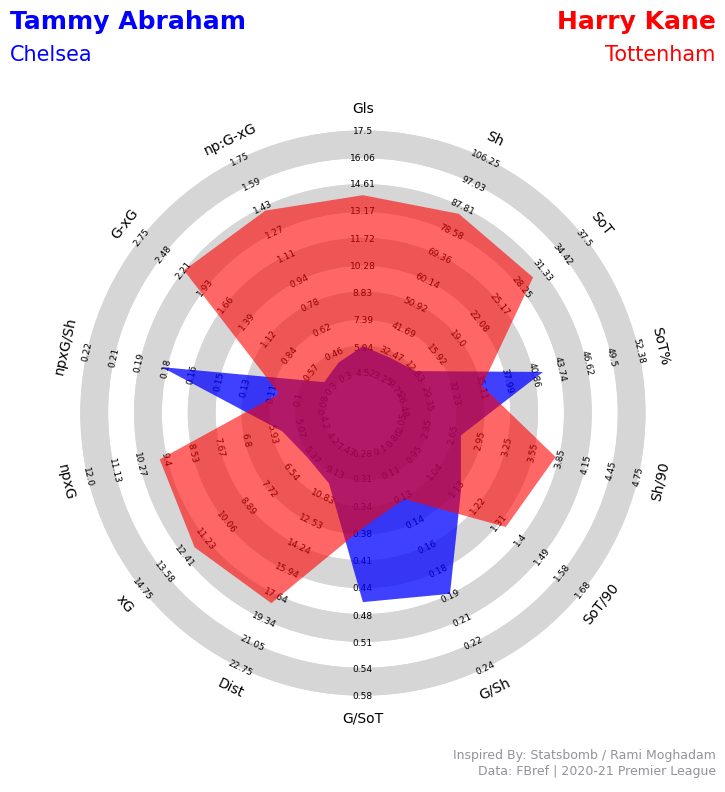

In [8]:
# The title dict is soccerplots' configuration object for the radar chart header.
# It supports two player entries (primary and secondary) with independent name,
# color, club subtitle, and font size settings. title_name_2 and subtitle_name_2
# correspond to the second player (Harry Kane). Colors should match radar_color.
title = dict(
    title_name='Tammy Abraham',
    title_color='blue',
    subtitle_name='Chelsea',
    subtitle_color='blue',
    title_name_2='Harry Kane',
    title_color_2='red',
    subtitle_name_2='Tottenham',
    subtitle_color_2='red',
    title_fontsize=18,
    subtitle_fontsize=15
)

endnote = 'Data: FBref | 2020-21 Premier League'

# Radar() instantiates the soccerplots radar renderer with default layout settings.
# radar.plot_radar() renders the dual-player comparison:
#   ranges: list of (min, max) tuples — one per axis, controls axis scaling
#   params: metric names displayed as axis labels
#   values: [[abraham_stats], [kane_stats]] — two stat vectors
#   radar_color: fill colors for each polygon (blue = Abraham, red = Kane)
#   alphas: polygon fill transparency. 0.75 for the first player (rendered first),
#           0.6 for the second (rendered on top, slightly more transparent to show overlap)
#   compare=True: activates dual-player overlay rendering mode
radar = Radar()

fig, ax = radar.plot_radar(
    ranges=ranges,
    params=params,
    values=values,
    radar_color=['blue', 'red'],
    alphas=[.75, .6],
    title=title,
    endnote=endnote,
    compare=True,
)

## Summary: Comparative Radar Chart — Dual Player Overlay

### What This Notebook Does

This notebook builds a comparative radar chart overlaying two players (Tammy Abraham and Harry Kane) across 14 attacking metrics for the 2020-21 Premier League season using the `soccerplots` library. Unlike the pizza chart in notebook 9 (which shows percentile ranks), this radar uses raw stat values scaled to per-axis ranges, enabling direct absolute value comparisons between two specific players.

### Key Concepts

- **Raw values vs percentiles**: The soccerplots `Radar` chart works with absolute stat values, not percentiles. Each axis is independently scaled between its `(min, max)` range so that the two polygon sizes reflect how each player compares relative to their own pair. This makes the chart more intuitive for direct head-to-head comparisons but less useful for showing where each player stands within their peer group.
- **Range construction with padding**: `a = min(df[col]) - min * 0.25` and `b = max(df[col]) + max * 0.25` expand each axis by 25% above and below the observed extreme values. Without this padding, a player whose value sits exactly at the observed min or max would be plotted at the very edge or center of the axis, making the polygon look either dominant or invisible on that axis regardless of actual performance.
- **Two-player range bias**: Computing `ranges` from only two players means the axis bounds are entirely determined by the pair. If Abraham scored 6 goals and Kane scored 14, the Gls axis spans approximately `[4.5, 17.5]`. Adding a third player (e.g., with 2 goals) would shift the lower bound, changing both polygons' visual shape without any change to the underlying data. For multi-player or squad comparisons, compute ranges from the full position-filtered population.
- **`compare=True`**: Activates soccerplots' dual-polygon rendering mode. Without it, only the first player's polygon is drawn. With it, both polygons are rendered with independent fill colors and transparency values, with the second drawn on top using a lower alpha to preserve overlap visibility.
- **`alphas=[0.75, 0.6]`**: The first player (Abraham) is rendered at 75% opacity; the second (Kane) at 60%. This ordering places Kane's polygon visually "on top" where the two overlap, making the more-dominant player (Kane, higher across most metrics) the foreground element.

### Data Available

| Object | Description |
|---|---|
| `df` | Two-row DataFrame with Abraham and Kane's 14 shooting metrics |
| `params` | List of 14 metric names used as radar axis labels |
| `ranges` | List of 14 `(min, max)` tuples defining each axis scale |
| `a_values` / `b_values` | Raw numeric stat lists for Abraham and Kane respectively |

### Ideas to Extract More Value

- **Population-based axis ranges**: Replace the two-player `min/max` with the full Premier League forward population's `min/max` for each metric. This anchors the axes to a consistent reference and makes the chart meaningful across any player pair.
- **Percentile radar hybrid**: Instead of raw values, compute percentile ranks within the full forward population (as in notebook 9) and pass those to the radar. This merges the "how do they compare to each other" view with the "how do they compare to all forwards" context.
- **Third player overlay**: Pass a third stat vector to `values` and a third color/alpha to `radar_color`/`alphas` to compare three players simultaneously — useful for scouting a specific role where two candidates are being evaluated against an existing player.
- **Metric grouping by category**: Organize `params` into logical groups (shooting volume, shooting efficiency, xG-based, distance) and use soccerplots' `group_color` parameter to color-code axis labels by group, making the chart easier to interpret at a glance.
- **Automated comparison batch**: Wrap `plot_radar` in a function that accepts two player names and returns the figure, then loop over a list of player pairs (e.g., every potential transfer target vs the squad's current striker) to generate a report of radar comparisons.